### TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("amazonreviews.tsv",sep="\t")

In [3]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.shape

(10000, 2)

In [5]:
df.columns

Index(['label', 'review'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
df.describe()

,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


In [8]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#Sentiment Distribution
print(df['label'].value_counts())

label
neg    5097
pos    4903
Name: count, dtype: int64


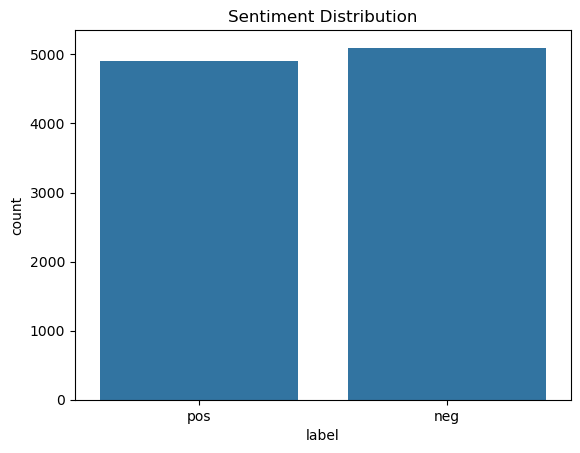

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [12]:
#Text Cleaning
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\komal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [13]:
#Cleaning Function
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
#Apply cleaning
import re
df['clean_review'] = df['review'].apply(clean_text)

In [15]:
#View Cleaned Data 
df[['review','clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [18]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


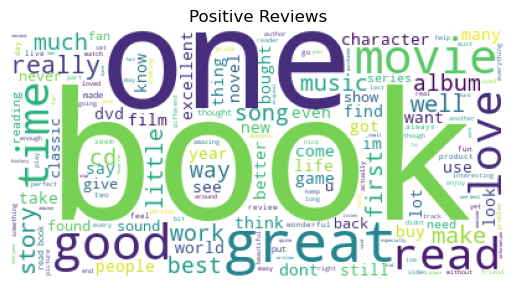

In [19]:
#  Word Cloud      
from wordcloud import WordCloud

# Positive Review
positive = " ".join(df[df['label']=="pos"]['clean_review'])

wordcloud = WordCloud(background_color="white").generate(positive)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews")

plt.show()

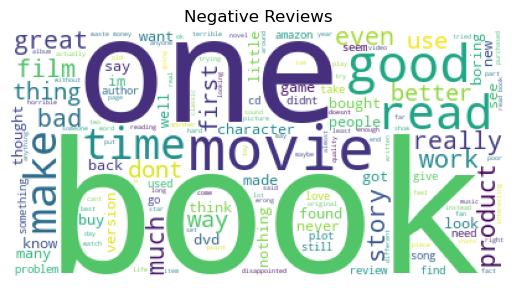

In [20]:
#Negative Reviews
negative = " ".join(df[df['label']=="neg"]['clean_review'])

wordcloud = WordCloud(background_color="white").generate(negative)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews")

plt.show()

In [22]:
#TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['label']

In [24]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

In [25]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
#Prediction
y_pred = lr.predict(X_test)

In [30]:
#Evaluation
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
print("Accuracy :",accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.8525
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

[[874 145]
 [150 831]]


In [32]:
#Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score( lr, X, y, cv=5 )

print(scores)

print("Average Accuracy :",scores.mean())

[0.8595 0.8335 0.828  0.831  0.849 ]
Average Accuracy : 0.8402


In [34]:
#Support Vector Machine (SVM)
from sklearn.svm import LinearSVC
svm = LinearSVC()

svm.fit(X_train,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [35]:
#Prediction
svm_pred = svm.predict(X_test)

In [36]:
#Evaluation
print("Accuracy :",accuracy_score(y_test,svm_pred))

print(classification_report(y_test,svm_pred))

print(confusion_matrix(y_test,svm_pred))

Accuracy : 0.843
              precision    recall  f1-score   support

         neg       0.85      0.84      0.84      1019
         pos       0.83      0.85      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

[[853 166]
 [148 833]]


In [37]:
#Compare Models
comparison = pd.DataFrame({

'Model':[
'Logistic Regression',
'SVM'
],

'Accuracy':[
accuracy_score(y_test,y_pred),
accuracy_score(y_test,svm_pred)
]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.8525
1,SVM,0.8430


In [38]:
#Conclusion
print(comparison)

                 Model  Accuracy
0  Logistic Regression    0.8525
1                  SVM    0.8430


## Conclusion
The dataset was successfully preprocessed by removing missing values (if any), duplicates, and cleaning the review text.
TF-IDF was used to convert text into numerical features.
Logistic Regression and Linear SVM were trained for sentiment classification.
Both models achieved good performance, and the model with the higher accuracy is selected as the better classifier.
The developed sentiment analysis system can automatically classify Amazon product reviews as positive or negative, helping businesses monitor customer feedback efficiently.